# ChIP-seq profiles at boundaries split by compartments

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import bioframe as bf
import bbi

from functools import partial
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map

from pathlib import Path

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
import cooler
import cooltools

In [3]:
sns.set_context('talk')

## E1 track calcuation

### Parameters

In [4]:
BINSIZE = 50_000
HG19_PATH = "/groups/gerlich/experiments/Experiments_005900/005975/data/input/hg19.fa"  # use your own file or download from the Genome Browser
CLR_PATH = "/groups/gerlich/experiments/Experiments_006500/006575/coolers_repo/WT_G2/WT_G2.all.mcool" + f"::/resolutions/{BINSIZE}"

### Calculate GC track

In [5]:
clr = cooler.Cooler(CLR_PATH)
bins_df = clr.bins()[:][['chrom', 'start', 'end']]

In [6]:
%%time
hg19_genome = bf.load_fasta(HG19_PATH)
gc_track = bf.frac_gc(bins_df, hg19_genome)

CPU times: user 29 s, sys: 6.54 s, total: 35.5 s
Wall time: 35.8 s


In [7]:
gc_track.head()

,chrom,start,end,GC
0,chr1,0,50000,0.484250
1,chr1,50000,100000,0.376740
2,chr1,100000,150000,0.429960
3,chr1,150000,200000,0.447314
4,chr1,200000,250000,0.410796


### Get E1 table

In [8]:
%%time
cis_eigs = cooltools.eigs_cis(clr, gc_track, n_eigs=1)

CPU times: user 1min 29s, sys: 17 s, total: 1min 46s
Wall time: 1min 10s


In [9]:
eigenvector_track = cis_eigs[1][['chrom', 'start', 'end', 'E1']]

QC: look at the track for chr1

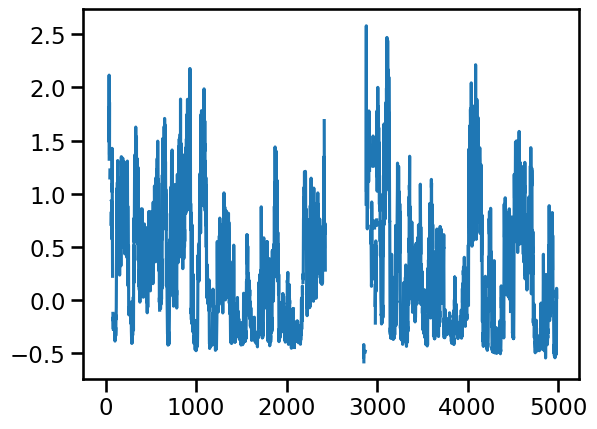

In [10]:
plt.plot(eigenvector_track.query('chrom == "chr1"')['E1'])

Looks like an eigenvector track.

In [11]:
eigenvector_track['compartment'] = eigenvector_track['E1'].map(lambda x: 'A' if x > 0 else 'B')

## Annotate boundaries with compartment type

Approach: annotate compartment types of "TADs" left and right of each boundary. If both TADs are in the same compartment, then boundary belongs to that same compartment. If TADs are in different compartments, then the boundary is a compartment boundary.

"TADs" upstream and downstream a boundary are defined as 250Kb long regions at 50Kb resoultion, i.e. 5 Hi-C bins. The compartment type of a "TAD" is determined based on the compartment types of the corresponding bins by the majority rule.

### Load boundaries

In [12]:
BOUNDARIES_PATH = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet'

In [13]:
boundaries = pd.read_parquet(BOUNDARIES_PATH)

Ensure that there are no boundaries on chrY and chrM.

In [14]:
boundaries['chrom'].unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
       'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15',
       'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22',
       'chrX'], dtype=object)

For each 10Kb long boundary get the index of an overlapping 50Kb long bin from the eigenvector table. Output is dict \[boundary index -> bin index\].

### Overlap boundaries with compartment annotation

In [15]:
boundaries_w_comp = bf.overlap(boundaries,
                               eigenvector_track[['chrom', 'start', 'end', 'compartment']],
                               how='left')\
                      .rename(columns={'compartment_': 'compartment'})\
                      .drop(['chrom_', 'start_', 'end_'], axis=1)

In [16]:
boundaries_w_comp.shape[0] == boundaries.shape[0]

True

We know it is 1-to-1 matching between a 10Kb long TAD boundary and a 50Kb long bin b/c of how binning procedure works.

## ChIP-seq signals

### ChIP-seq paths

In [17]:
TRACKS_DIR = Path('/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/')
track_paths = {'Sororin': TRACKS_DIR / 'Sororin/WT_G2/Sororin_WT_G2.chip.bw',
               'RAD21': TRACKS_DIR / 'RAD21/WT_G2/RAD21_WT_G2.chip.bw'}

In [18]:
CN_PATH = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/copy_numbers/cnv_seg.bw'

### Estimate averages with new resolution

In [19]:
chromsizes = bf.fetch_chromsizes('hg19')

In [20]:
copy_numbers_vecs = {chrom: bbi.fetch(CN_PATH, chrom, 0, size, bins=size // 1_000, missing=np.nan)
                     for chrom, size in chromsizes.items() if chrom not in ('chrY', 'chrM')}

In [21]:
def get_binned_mean(track, chromsizes, binsize):
    chrom_means = list()
    for chrom, size in chromsizes.items():
        if chrom in ('chrY', 'chrM'):
            continue
        vec = bbi.fetch(str(track), chrom, 0, size, bins=size//binsize, missing=np.nan)
        norm_vec = vec / copy_numbers_vecs[chrom]
        norm_vec[np.isinf(norm_vec)] = np.nan
        chrom_means.append(np.nanmean(norm_vec))
    return np.nanmean(chrom_means)

In [22]:
gw_means = dict()
for protein, path in tqdm(track_paths.items()):
    new_mean = get_binned_mean(path, chromsizes, 1_000)
    gw_means[protein] = new_mean

  0%|          | 0/2 [00:00<?, ?it/s]

In [23]:
gw_means

{'Sororin': 0.033853500467369214, 'RAD21': 0.0310693479064608}

### Extraction functions

In [24]:
def _extract_signal_chunk(df, path, bins=-1, summary='mean', missing=0):
    with bbi.open(path) as f:
        hmap = f.stackup(df['chrom'], df['start'], df['end'], bins=bins, summary=summary, missing=missing)
    return hmap


def extract_signal(df, path, bins=-1, summary='mean', missing=0, chunks=1, cores=1):
    df_chuncks = np.array_split(df, chunks)
    func = partial(_extract_signal_chunk, path=str(path), bins=bins, summary=summary, missing=missing)
    results = process_map(func, df_chuncks, max_workers=cores, desc='chunk')
    return np.concatenate(results)

### Create windows

I want to create TAD boundary +- 100Kb.

In [25]:
midpoints = (boundaries_w_comp['start'] + boundaries_w_comp['end']) // 2

In [26]:
windows = pd.DataFrame({'chrom': boundaries_w_comp['chrom'],
                        'start': midpoints - 100_000,
                        'end': midpoints + 100_000})

### Get signals

I want to get 1Kb resolution -> 201 bins for +-100Kb.

In [27]:
BINS = 201

In [28]:
copy_numbers_hmap = extract_signal(windows, CN_PATH, bins=BINS, missing=np.nan, chunks=100, cores=8)
copy_numbers_hmap[copy_numbers_hmap == 0] = np.nan

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

In [29]:
heatmaps = dict()
for protein, path in track_paths.items():
    signal = extract_signal(windows, path, bins=BINS, missing=np.nan, chunks=100, cores=8)
    norm_signal = signal / copy_numbers_hmap
    heatmaps[protein] = norm_signal

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

## Make average plots

In [30]:
condition_palettes = {'Sororin': 'darkred',
                      'RAD21': 'darkblue'}

In [31]:
alpha_levels = {'high': 1,
                'med': .6,
                'low': .2}

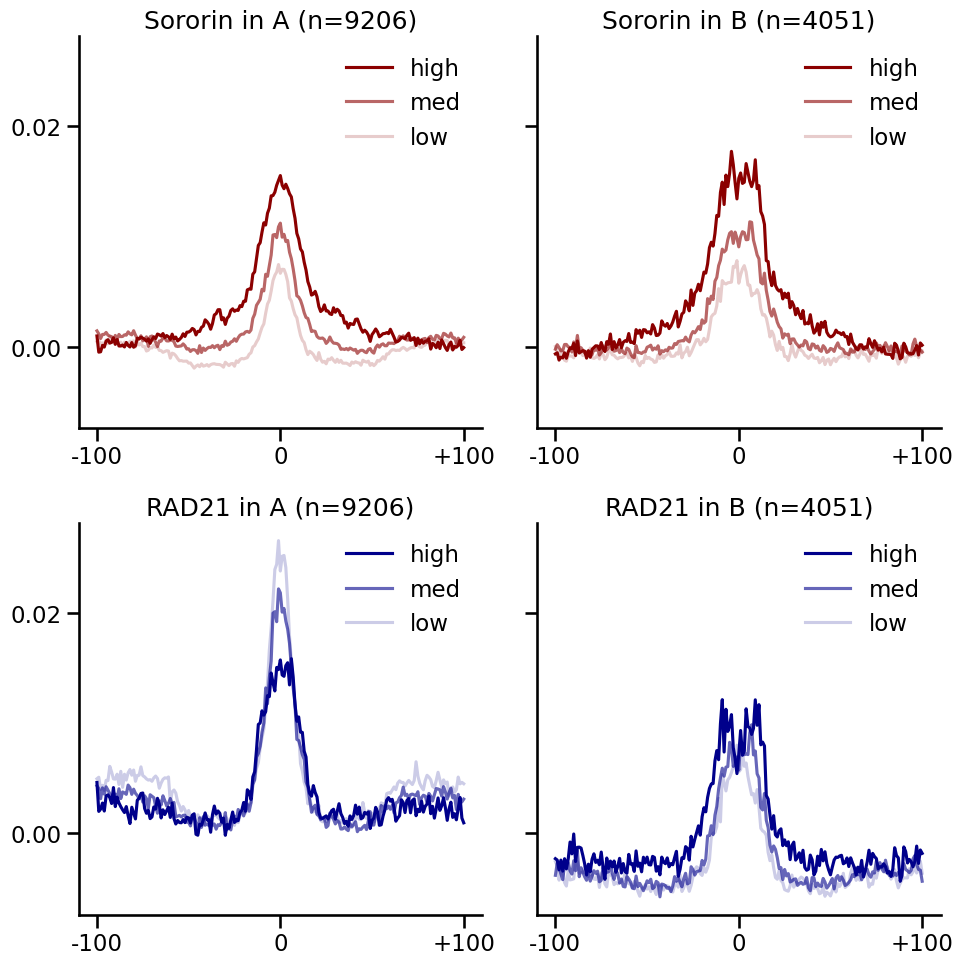

In [32]:
with sns.plotting_context('talk'):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=100, sharey=True)
    for row_idx, (protein, hmap) in enumerate(heatmaps.items()):
        for col_idx, comp in enumerate(('A', 'B')):
            plt.sca(axes[row_idx, col_idx])
            comp_subset = boundaries_w_comp.query(f"compartment == '{comp}'")
            for title, df in comp_subset.groupby('levelGroup'):
                idx = df.index
                profile = np.nanmean(hmap[idx, :], axis=0)
                norm_profile = profile - gw_means[protein]
                plt.plot(norm_profile,
                         label=title,
                         color=condition_palettes[protein],
                         zorder=3,
                         alpha=alpha_levels[title])
            plt.legend(edgecolor='none')
            plt.xticks([0, 100, 200], ['-100', '0', '+100'])
            plt.gca().yaxis.set_major_locator(plt.MaxNLocator(2))
            plt.title(f"{protein} in {comp} (n={comp_subset.shape[0]})")
            sns.despine()
    plt.tight_layout()